<a href="https://colab.research.google.com/github/Nosreme1234/DataScie-Physionet/blob/main/Brugada_HUCA_12_Lead.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install wfdb
%pip install seaborn



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 92.2 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.


## Import Library

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
import seaborn as sns

In [5]:
!wget -r -N -c -np https://physionet.org/files/brugada-huca/1.0.0/

Streaming output truncated to the last 5000 lines.
Length: 28800 (28K) [application/octet-stream]
Saving to: ‘physionet.org/files/brugada-huca/1.0.0/files/1297151/1297151.dat’

physionet.org/files 100%[===================>]  28.12K  --.-KB/s    in 0.06s   

2026-03-08 14:21:36 (468 KB/s) - ‘physionet.org/files/brugada-huca/1.0.0/files/1297151/1297151.dat’ saved [28800/28800]

--2026-03-08 14:21:36--  https://physionet.org/files/brugada-huca/1.0.0/files/1297151/1297151.hea
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 601 [text/plain]
Saving to: ‘physionet.org/files/brugada-huca/1.0.0/files/1297151/1297151.hea’

physionet.org/files 100%[===================>]     601  --.-KB/s    in 0s      

2026-03-08 14:21:36 (215 MB/s) - ‘physionet.org/files/brugada-huca/1.0.0/files/1297151/1297151.hea’ saved [601/601]

--2026-03-08 14:21:36--  https://physionet.org/files/brugada-huca/1.0.0/files/1297765/1297765.dat
Reusing existing connectio

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Metadata Variable

In [9]:
metadata_dictionary = pd.read_csv('metadata_dictionary.csv')
metadata_dictionary.head()

FileNotFoundError: [Errno 2] No such file or directory: 'metadata_dictionary.csv'

| Variabel | Deskripsi |
|----|---- |
| patient_id | Pengidentifikasi unik untuk setiap pasien |
| diagnosis | Diagnosis untuk pasien |
| sudden_death | Apakah pasien mengalami kematian mendadak |
| basal_pattern | Apakah EKG menunjukkan pola Brugada |
| Brugada | Pasien didiagnosis sindrom brugada |


## Loading the Dataset

### Reading Metadata

In [ ]:
metadata = pd.read_csv('metadata.csv')
metadata.head()

,patient_id,basal_pattern,sudden_death,brugada
0,188981,1,0,1
1,251972,0,0,0
2,265715,0,0,0
3,267628,0,0,0
4,267630,0,0,1


In [ ]:
print(f"Total subjects: {len(metadata)}")
print(f"Brugada patients: {(metadata['brugada'] > 0).sum()}")
print(f"Healthy subjects: {(metadata['brugada'] == 0).sum()}")

Total subjects: 363
Brugada patients: 76
Healthy subjects: 287


### Read ECG (Electrocardiogram) Signals


In [ ]:
# patien_id with brugada type 2: 460919
# patiend_id with brugada type 1: 419960
# patiend_id normal: 251972
patient_id = '292666'


record = wfdb.rdrecord(f'files/{patient_id}/{patient_id}')

In [ ]:
signals = record.p_signal
lead_names = record.sig_name
sampling_freq = record.fs

print(f"Sampling rate: {record.fs} Hz")
print(f"Lead names: {record.sig_name}")
print(f"Duration: {len(record.p_signal / record.fs)} seconds")
print(f"Data shape: {signals.shape}")


Sampling rate: 100 Hz
Lead names: ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Duration: 1200 seconds
Data shape: (1200, 12)


### Read first lead ECG

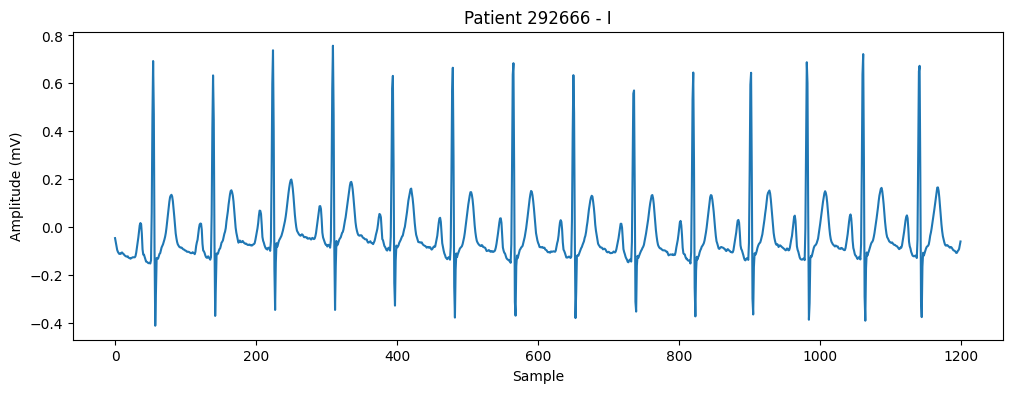

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(signals[:, 0])
plt.title(f'Patient {patient_id} - {lead_names[0]}')
plt.xlabel('Sample')
plt.ylabel('Amplitude (mV)')
plt.show()

### Read all lead ECG - patient_id

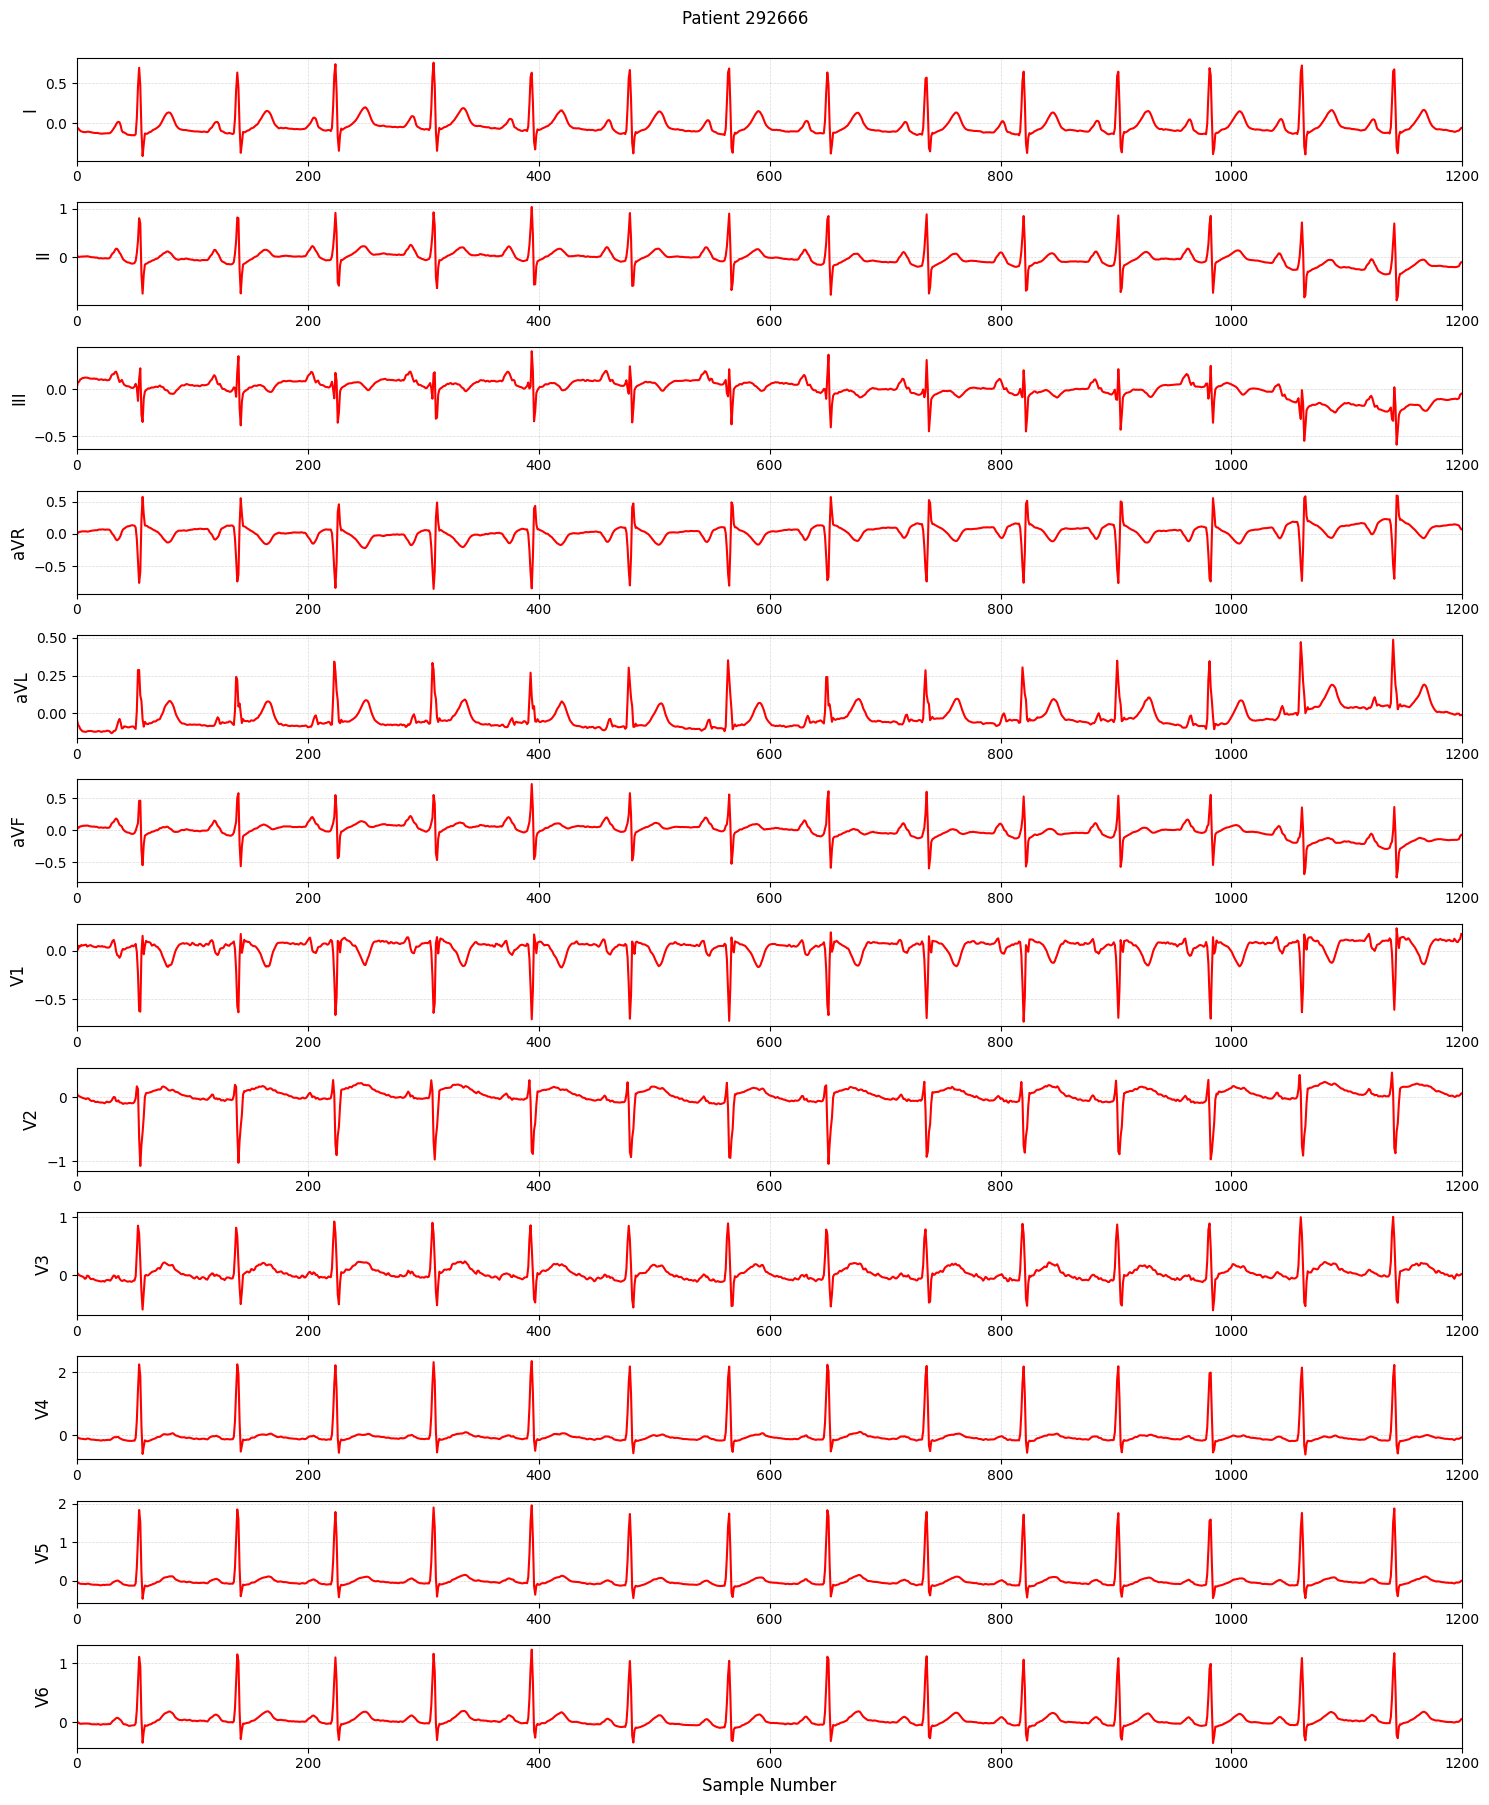

In [ ]:
fig, axes = plt.subplots(12, 1, figsize=(15, 18))

for i, lead_name in enumerate(record.sig_name):
  axes[i].plot(signals[:, i], linewidth=1.5, color='red')
  axes[i].set_ylabel(lead_name, fontsize=12, fontweight='medium')
  axes[i].grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.3)
  axes[i].set_xlim(0, len(signals))

plt.suptitle(f'Patient {patient_id}', y=1)
plt.xlabel('Sample Number', fontsize=12)
plt.tight_layout()
plt.show()

## Exploratory Data Analysis

In [ ]:
df = pd.DataFrame(signals, columns=lead_names)
df.head()

NameError: name 'pd' is not defined

## Data Preprocessing

In [ ]:
## TODO: Data Preprocessing

## Feature Engineering

In [ ]:
## TODO: Feature Engineering

## Modeling

In [ ]:
## TODO: Modeling

## Validation

In [ ]:
## TODO: Validation